In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
%pip install xgboost


In [3]:
from xgboost import XGBRegressor

In [6]:
#Step 2. Create a normal regression dataset

#Start with a simple relationship.

#Suppose:

#$$ Y = 3 + 2X_1 + 1.5X_2 - X_3 + \epsilon $$

#Generate 1,000 observations.
np.random.seed(42)

n = 1000

X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
X3 = np.random.normal(0, 1, n)

error = np.random.normal(0, 1, n)

Y = 3 + 2*X1 + 1.5*X2 - X3 + error

df = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "Y": Y
})

df.head()

,X1,X2,X3,Y
0,0.496714,1.399355,-0.675178,4.859832
1,-0.138264,0.924634,-0.144519,3.394556
2,0.647689,0.059630,-0.792420,4.763637
3,1.523030,-0.646937,-0.307962,7.271304
4,-0.234153,0.698223,-1.893615,6.029196


In [7]:
#Step 3. Split the data
X = df[["X1", "X2", "X3"]]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#80% training, 20% testing.

In [8]:
#Step 4. Create a function to compare models
def evaluate_models(X_train, X_test, y_train, y_test):

    models = {
        "OLS": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Huber": HuberRegressor(),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, random_state=42
        ),
        "XGBoost": XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
    }

    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

    return pd.DataFrame(results)

In [9]:
results = evaluate_models(
    X_train, X_test, y_train, y_test
)

results

,Model,RMSE,MAE,R2
0,OLS,1.036938,0.827121,0.876029
1,Ridge,1.037339,0.827542,0.875933
2,Huber,1.037429,0.828090,0.875911
3,Random Forest,1.228379,0.956959,0.826028
4,XGBoost,1.132448,0.897738,0.852140


In [10]:
def generate_heteroscedastic_data(
    n=1000,
    seed=None
):

    if seed is not None:
        np.random.seed(seed)

    X1 = np.random.normal(0, 1, n)
    X2 = np.random.normal(0, 1, n)
    X3 = np.random.normal(0, 1, n)

    error_sd = 0.5 + 1.5 * np.abs(X1)

    error = np.random.normal(
        0,
        error_sd,
        n
    )

    Y = (
        3
        + 2 * X1
        + 1.5 * X2
        - X3
        + error
    )

    return pd.DataFrame({
        "X1": X1,
        "X2": X2,
        "X3": X3,
        "Y": Y
    })

In [11]:
#Run experiment
data = generate_heteroscedastic_data(
    n=1000,
    seed=42
)

X = data[["X1", "X2", "X3"]]
y = data["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

hetero_results = evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test
)

hetero_results

,Model,RMSE,MAE,R2
0,OLS,1.786699,1.332272,0.701158
1,Ridge,1.787095,1.332826,0.701025
2,Huber,1.783257,1.328901,0.702308
3,Random Forest,2.017521,1.482035,0.618956
4,XGBoost,1.936975,1.424232,0.648774


In [12]:
#Save
hetero_results.to_csv(
    "../results/tables/heteroscedasticity_results.csv",
    index=False
)

<ipython-input-13-f111c0c085f7>:15: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig(
<ipython-input-13-f111c0c085f7>:15: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig(


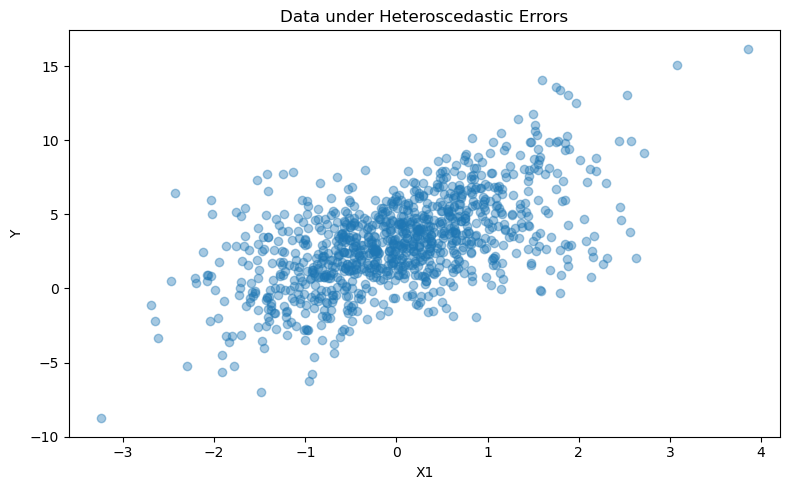

In [13]:
#Visualize the violation
plt.figure(figsize=(8, 5))

plt.scatter(
    data["X1"],
    data["Y"],
    alpha=0.4
)

plt.xlabel("X1")
plt.ylabel("Y")
plt.title("Data under Heteroscedastic Errors")

plt.tight_layout()

plt.savefig(
    "../results/figures/heteroscedasticity_data.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()